In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect("../database/air_quality.db")

In [3]:
query = "SELECT * FROM air_quality"

df = pd.read_sql_query(query, conn)

df.head()

,id,timestamp,aqi,pm2_5,pm10,co,no2,o3,so2,calculated_aqi,primary_pollutant
0,1,2026-07-17 14:54:48,4,64.12,66.66,508.77,3.62,129.69,4.91,155.0,pm2_5
1,2,2026-07-17 14:55:44,4,64.12,66.66,508.77,3.62,129.69,4.91,155.0,pm2_5
2,3,2026-07-17 15:00:02,4,64.12,66.66,508.77,3.62,129.69,4.91,155.0,pm2_5
3,4,2026-07-17 16:03:49,4,71.83,75.19,522.48,4.51,134.23,5.20,159.0,pm2_5
4,5,2026-07-17 18:39:46,5,80.25,88.38,734.61,17.07,89.47,7.83,164.0,pm2_5


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371 entries, 0 to 370
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 371 non-null    int64  
 1   timestamp          371 non-null    object 
 2   aqi                371 non-null    int64  
 3   pm2_5              371 non-null    float64
 4   pm10               371 non-null    float64
 5   co                 371 non-null    float64
 6   no2                371 non-null    float64
 7   o3                 371 non-null    float64
 8   so2                371 non-null    float64
 9   calculated_aqi     371 non-null    float64
 10  primary_pollutant  371 non-null    object 
dtypes: float64(7), int64(2), object(2)
memory usage: 32.0+ KB


In [5]:
df.describe()

,id,aqi,pm2_5,pm10,co,no2,o3,so2,calculated_aqi
count,371.000000,371.000000,371.000000,371.000000,371.000000,371.000000,371.000000,371.000000,371.000000
mean,186.000000,3.091644,40.202183,45.938356,589.312668,14.196173,54.003612,6.560593,107.789757
std,107.242715,0.907751,19.607953,22.776652,245.020582,8.312154,32.663811,1.984247,37.386209
min,1.000000,1.000000,7.140000,8.460000,248.980000,1.890000,0.220000,2.820000,30.000000
25%,93.500000,3.000000,27.075000,30.145000,386.060000,7.435000,29.940000,5.220000,82.500000
50%,186.000000,3.000000,36.930000,40.430000,547.200000,12.800000,52.060000,6.300000,105.000000
75%,278.500000,4.000000,52.540000,61.395000,729.595000,18.985000,74.600000,7.550000,143.000000
max,371.000000,5.000000,97.470000,119.310000,1310.840000,39.280000,146.150000,16.110000,173.000000


In [6]:
df.isnull().sum()

id                   0
timestamp            0
aqi                  0
pm2_5                0
pm10                 0
co                   0
no2                  0
o3                   0
so2                  0
calculated_aqi       0
primary_pollutant    0
dtype: int64

In [7]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [8]:
df.isnull().sum()

id                   0
timestamp            0
aqi                  0
pm2_5                0
pm10                 0
co                   0
no2                  0
o3                   0
so2                  0
calculated_aqi       0
primary_pollutant    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.dtypes

id                            int64
timestamp            datetime64[ns]
aqi                           int64
pm2_5                       float64
pm10                        float64
co                          float64
no2                         float64
o3                          float64
so2                         float64
calculated_aqi              float64
primary_pollutant            object
dtype: object

In [13]:
#feature engineering
df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day
df["weekday"] = df["timestamp"].dt.day_name()
df.tail()

,id,timestamp,aqi,pm2_5,pm10,co,no2,o3,so2,calculated_aqi,primary_pollutant,hour,day,weekday
366,367,2026-08-21 14:03:44,3,41.67,43.78,361.43,2.81,106.07,4.40,116.0,pm2_5,14,21,Friday
367,368,2026-08-21 16:29:06,3,39.99,42.95,383.73,5.94,99.59,5.42,112.0,pm2_5,16,21,Friday
368,369,2026-08-21 17:03:44,3,39.99,42.95,383.73,5.94,99.59,5.42,112.0,pm2_5,17,21,Friday
369,370,2026-08-21 17:48:14,3,39.89,43.42,414.43,9.05,88.95,6.30,112.0,pm2_5,17,21,Friday
370,371,2026-08-21 18:03:44,3,39.89,43.42,414.43,9.05,88.95,6.30,112.0,pm2_5,18,21,Friday


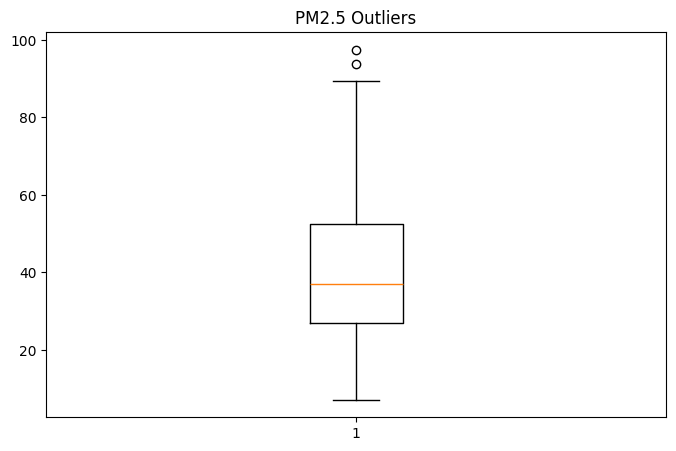

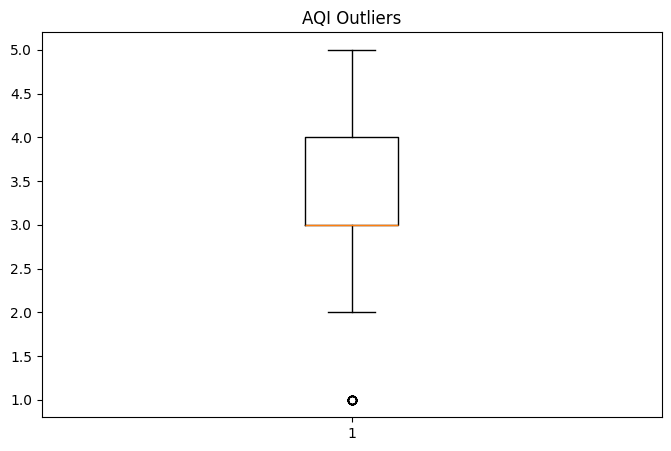

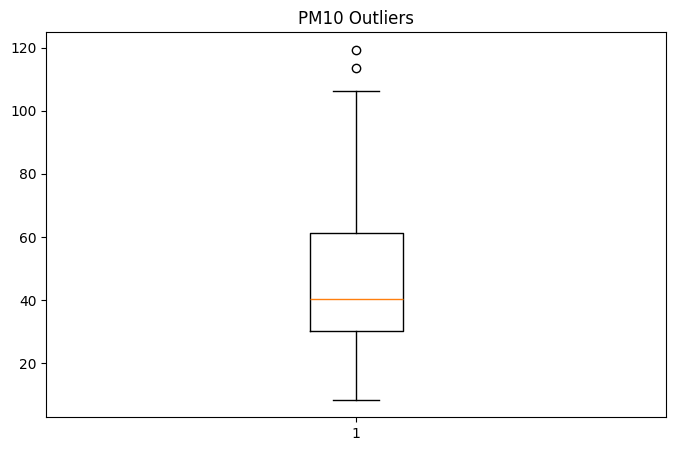

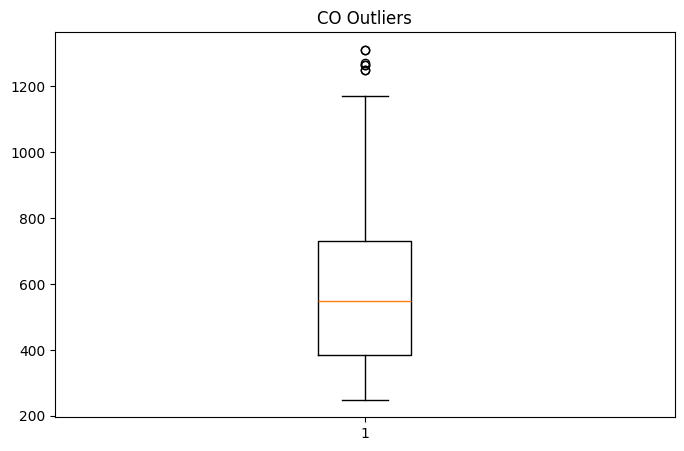

In [14]:
#checking for outliers using boxplots
plt.figure(figsize=(8,5))
plt.boxplot(df["pm2_5"])
plt.title("PM2.5 Outliers")
plt.show()

plt.figure(figsize=(8,5))
plt.boxplot(df["aqi"])
plt.title("AQI Outliers")
plt.show()

plt.figure(figsize=(8,5))
plt.boxplot(df["pm10"])
plt.title("PM10 Outliers")
plt.show()

plt.figure(figsize=(8,5))
plt.boxplot(df["co"])
plt.title("CO Outliers")
plt.show()



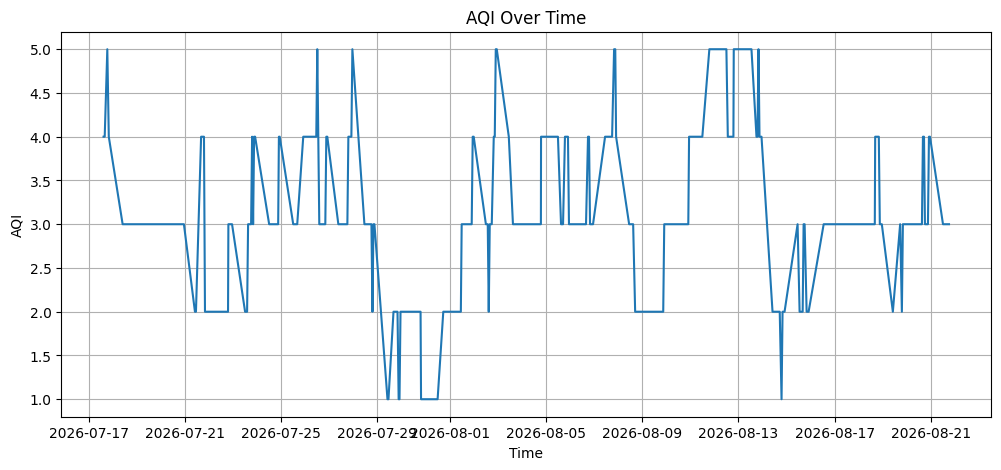

In [15]:
#aqi trend
plt.figure(figsize=(12,5))

plt.plot(df["timestamp"], df["aqi"])

plt.xlabel("Time")

plt.ylabel("AQI")

plt.title("AQI Over Time")

plt.grid(True)

plt.show()

In [16]:
#correlation matrix
corr = df.corr(numeric_only=True)
corr

,id,aqi,pm2_5,pm10,co,no2,o3,so2,calculated_aqi,hour,day
id,1.000000,0.119047,0.121084,0.147634,-0.136863,-0.178523,0.191090,0.140812,0.119643,0.071491,-0.348017
aqi,0.119047,1.000000,0.934814,0.916725,0.555413,0.324724,0.121210,0.574271,0.923414,0.069068,-0.352510
pm2_5,0.121084,0.934814,1.000000,0.986684,0.599164,0.359806,0.124211,0.633707,0.974344,0.101572,-0.357386
pm10,0.147634,0.916725,0.986684,1.000000,0.660709,0.438977,0.028839,0.692614,0.958927,0.184831,-0.364732
co,-0.136863,0.555413,0.599164,0.660709,1.000000,0.901622,-0.663301,0.723732,0.618488,0.192232,-0.388222
no2,-0.178523,0.324724,0.359806,0.438977,0.901622,1.000000,-0.804457,0.731470,0.371082,0.286761,-0.246257
o3,0.191090,0.121210,0.124211,0.028839,-0.663301,-0.804457,1.000000,-0.352992,0.106507,-0.175465,0.173454
so2,0.140812,0.574271,0.633707,0.692614,0.723732,0.731470,-0.352992,1.000000,0.616400,0.282744,-0.283928
calculated_aqi,0.119643,0.923414,0.974344,0.958927,0.618488,0.371082,0.106507,0.616400,1.000000,0.078921,-0.384128
hour,0.071491,0.069068,0.101572,0.184831,0.192232,0.286761,-0.175465,0.282744,0.078921,1.000000,0.020164


In [17]:
df.to_csv("../data/processed_air_quality.csv",index=False)

In [18]:
df.to_sql(
    "processed_air_quality",
    conn,
    if_exists="replace",
    index=False
)

371

In [19]:
conn.close()